<a href="https://colab.research.google.com/github/yaj0212/Introductory-Machine-Learning/blob/main/Step_2_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 从 Google Cloud Storage (GCS) 读取大文件

请确保您已经将您的 3GB CSV 文件上传到了 Google Cloud Storage 中的一个存储桶里。如果您还没有安装 `gcloud CLI` 并使用 `gsutil` 命令上传，请参考上方的说明。

在 Colab 中，您可以直接访问 GCS 文件。下面的代码会安装 `gcsfs` 库，它允许 `pandas` 直接从 `gs://` 路径读取数据。您需要将 `YOUR_BUCKET_NAME` 和 `YOUR_FILE_NAME.csv` 替换为您的实际存储桶名称和文件名。

In [1]:
from google.colab import auth

auth.authenticate_user()

Google Cloud 身份验证完成。
请确保您已授权正确的 Google 帐户，并且该帐户对 '550_project' 存储桶具有读取权限。


在您完成上述身份验证后，请**再次尝试运行读取 GCS 文件的代码单元格** (`ee8a82b8`)。确保您已经将 `gcs_file_path` 中的 `YOUR_FILE_NAME.csv` 替换为实际的文件名。

In [4]:
!pip install gcsfs

import pandas as pd

gcs_file_path = 'gs://550_project/train_split.csv'

try:
    train_split = pd.read_csv(gcs_file_path)
    print("The file has been successfully read from GCS.")
    display(train_split.head())
except Exception as e:
    print(f"An Error was occurred while reading the file: {e}")


The file has been successfully read from GCS.


,author,created_utc,score,selftext,subreddit,title,timestamp,title_clean,selftext_clean,text,...,word_count,char_count,id,url,created,d_,author_norm,text_norm,period,label
0,Malamute-Master-Race,1620148637,1,\nBasically the title. But this leads to lots ...,Anxiety,How can I build self esteem when I don’t belie...,2021-05-05 03:17:17,How can I build self esteem when I don’t belie...,Basically the title. But this leads to lots of...,How can I build self esteem when I don’t belie...,...,48,269,NaN,NaN,NaN,NaN,malamute-master-race,how can i build self esteem when i don’t belie...,late_covid,0
1,demandingdove,1610898298,1,[removed],depression,I feel like I'm trapped.,2021-01-18 02:44:58,I feel like I'm trapped.,NaN,I feel like I'm trapped.,...,5,24,NaN,NaN,NaN,NaN,demandingdove,i feel like i'm trapped.,late_covid,1
2,Smartt88,1599573567,1,Does anyone else experience this? Often when I...,Anxiety,Telling myself “things are okay” manually make...,2020-09-08 23:59:27,Telling myself “things are okay” manually make...,Does anyone else experience this? Often when I...,Telling myself “things are okay” manually make...,...,154,886,NaN,NaN,NaN,NaN,smartt88,telling myself “things are okay” manually make...,early_covid,0
3,TroubledFig,1547014831,1,So I've been working out for about 2 year's no...,depression,Being active didn't help me...,2019-01-09 17:20:31,Being active didn't help me...,So I've been working out for about 2 year's no...,Being active didn't help me... So I've been wo...,...,62,325,NaN,NaN,NaN,NaN,troubledfig,being active didn't help me... so i've been wo...,pre_covid,1
4,Ralen_Hlaalo,1618871905,1,I’m 32 and am constantly thinking about ageing...,depression,I obsess over the passage of time,2021-04-20 08:38:25,I obsess over the passage of time,I’m 32 and am constantly thinking about ageing...,I obsess over the passage of time I’m 32 and a...,...,149,796,NaN,NaN,NaN,NaN,ralen_hlaalo,i obsess over the passage of time i’m 32 and a...,late_covid,1


In [5]:
gcs_file_path = 'gs://550_project/test_split.csv'
test_split = pd.read_csv(gcs_file_path)
print("The file has been successfully read from GCS.")

The file has been successfully read from GCS.


In [6]:
gcs_file_path = 'gs://550_project/train_anxiety_depression.csv'
train_anxiety_depression = pd.read_csv(gcs_file_path)
print("The file has been successfully read from GCS.")

/tmp/ipykernel_788/2668232798.py:2: DtypeWarning: Columns (23,24,26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_anxiety_depression = pd.read_csv(gcs_file_path)


The file has been successfully read from GCS.


In [7]:
gcs_file_path = 'gs://550_project/suicidewatch_inference.csv'
suicidewatch_inference = pd.read_csv(gcs_file_path)
print("The file has been successfully read from GCS.")

The file has been successfully read from GCS.


In [8]:
gcs_file_path = 'gs://550_project/val_split.csv'
val_split = pd.read_csv(gcs_file_path)
print("The file has been successfully read from GCS.")

The file has been successfully read from GCS.


In [30]:
import os
import subprocess
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [20]:
# Configuration
GCS_BUCKET = "gs://550_project"

CONFIG = {
    # Model
    "model_name":      "bert-base-uncased",
    "num_labels":      2,               # anxiety=0, depression=1
    "max_length":      256,
    "dropout":         0.3,

    # Sampling
    "sample_per_class": 40000,          # 40000 per class = 60000 total

    # Training
    "batch_size":      16,
    "lr":              2e-5,
    "epochs":          5,
    "warmup_ratio":    0.1,
    "weight_decay":    0.01,
    "num_workers":     2,

    # Probing heads
    "probing_lr":      1e-3,
    "probing_epochs":  3,
    "probing_batch":   256,

    # Output
    "checkpoint_dir":  "checkpoints",
    "output_dir":      "quarter_scores",
}

LABEL2ID = {"anxiety": 0, "depression": 1}
ID2LABEL  = {0: "anxiety", 1: "depression"}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Config ready.")

Config ready.


In [21]:
print(train_split["source_label"].unique())
print(train_split["source_label"].value_counts())

['anxiety' 'depression']
source_label
depression    418084
anxiety       173764
Name: count, dtype: int64


In [22]:
# Build Balanced Sample Training Set (40000 per class)
anxiety_sample    = (train_split[train_split["source_label"] == "anxiety"]
                     .sample(n=CONFIG["sample_per_class"], random_state=42))
depression_sample = (train_split[train_split["source_label"] == "depression"]
                     .sample(n=CONFIG["sample_per_class"], random_state=42))

sample_df = (pd.concat([anxiety_sample, depression_sample])
             .sample(frac=1, random_state=42)   # shuffle
             .reset_index(drop=True))

# Re-split sample into train / val / test (80 / 10 / 10)
from sklearn.model_selection import train_test_split

sample_train, sample_temp = train_test_split(
    sample_df, test_size=0.2, stratify=sample_df["label"], random_state=42
)
sample_val, sample_test = train_test_split(
    sample_temp, test_size=0.5, stratify=sample_temp["label"], random_state=42
)

print(f"Sample train: {len(sample_train):,}")
print(f"Sample val:   {len(sample_val):,}")
print(f"Sample test:  {len(sample_test):,}")
print(f"\nLabel distribution in sample_train:\n{sample_train['source_label'].value_counts()}")

Sample train: 64,000
Sample val:   8,000
Sample test:  8,000

Label distribution in sample_train:
source_label
anxiety       32000
depression    32000
Name: count, dtype: int64


In [23]:
# Dataset Classes
class MentalHealthDataset(Dataset):
    """Training / validation / test dataset."""
    def __init__(self, df, tokenizer, max_length=256):
        self.texts      = df["text"].fillna("").tolist()
        self.labels     = df["label"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }


class SuicideInferenceDataset(Dataset):
    """Inference dataset for suicidewatch posts — no labels."""
    def __init__(self, df, tokenizer, max_length=256):
        self.texts       = df["text"].fillna("").tolist()
        self.periods     = df["period"].tolist()
        self.year_months = df["year_month"].tolist()
        self.quarters    = df["quarter"].tolist()
        self.tokenizer   = tokenizer
        self.max_length  = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "period":         self.periods[idx],
            "year_month":     str(self.year_months[idx]),
            "quarter":        self.quarters[idx]
        }


def build_dataloaders(train_df, val_df, test_df, tokenizer, config):
    train_ds = MentalHealthDataset(train_df, tokenizer, config["max_length"])
    val_ds   = MentalHealthDataset(val_df,   tokenizer, config["max_length"])
    test_ds  = MentalHealthDataset(test_df,  tokenizer, config["max_length"])

    train_loader = DataLoader(train_ds, batch_size=config["batch_size"],
                              shuffle=True,  num_workers=config["num_workers"], pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=config["batch_size"],
                              shuffle=False, num_workers=config["num_workers"], pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=config["batch_size"],
                              shuffle=False, num_workers=config["num_workers"], pin_memory=True)
    return train_loader, val_loader, test_loader


def build_inference_loader(df, tokenizer, config):
    ds = SuicideInferenceDataset(df, tokenizer, config["max_length"])
    return DataLoader(ds, batch_size=config["batch_size"] * 2,
                      shuffle=False, num_workers=config["num_workers"], pin_memory=True)


print("Dataset classes defined.")

Dataset classes defined.


In [24]:
# Model Architecture
class BERTClassifier(nn.Module):
    """
    BERT fine-tuned for binary classification (anxiety vs depression).
    return_embedding=True  -> returns [CLS] embedding for probing heads
    return_embedding=False -> returns logits for classification training
    """
    def __init__(self, model_name, num_labels=2, dropout=0.3):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, return_embedding=False):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]   # [batch, 768]
        cls_emb = self.dropout(cls_emb)
        if return_embedding:
            return cls_emb
        return self.classifier(cls_emb)                 # [batch, 2]


class ProbingHead(nn.Module):
    """
    Lightweight binary classifier on frozen BERT embeddings.
    One head per dimension (anxiety / depression).
    Output: single logit -> sigmoid in [0,1] at inference time.
    """
    def __init__(self, input_dim=768, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embedding):
        return self.net(embedding)   # [batch, 1]


print("Model classes defined.")

Model classes defined.


In [25]:
# Training Utilities
def evaluate(model, loader, device, loss_fn):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)
            logits         = model(input_ids, attention_mask)
            loss           = loss_fn(logits, labels)
            total_loss    += loss.item()
            all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro"), all_preds, all_labels


def train_bert(model, train_loader, val_loader, config, device):
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    total_steps  = len(train_loader) * config["epochs"]
    warmup_steps = int(total_steps * config["warmup_ratio"])
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    scaler    = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    best_val_f1 = 0
    history     = []

    for epoch in range(config["epochs"]):
        model.train()
        total_loss = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']}")
        for batch in pbar:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)
            optimizer.zero_grad()

            if scaler:
                with torch.cuda.amp.autocast():
                    logits = model(input_ids, attention_mask)
                    loss   = loss_fn(logits, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(input_ids, attention_mask)
                loss   = loss_fn(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss          = total_loss / len(train_loader)
        val_loss, val_f1, _, _  = evaluate(model, val_loader, device, loss_fn)

        print(f"\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} "
              f"| Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f}")
        history.append({"epoch": epoch+1, "train_loss": avg_train_loss,
                         "val_loss": val_loss, "val_f1": val_f1})

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            ckpt_path   = os.path.join(config["checkpoint_dir"], "best_model.pt")
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "val_f1": val_f1,
                "config": config
            }, ckpt_path)
            print(f"  Saved best model -> {ckpt_path}  (Val F1={val_f1:.4f})")

    return history, best_val_f1


print("Training utilities defined.")

Training utilities defined.


In [26]:
# Fine-tune BERT
print("Initializing tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

train_loader, val_loader, test_loader = build_dataloaders(
    sample_train, sample_val, sample_test, tokenizer, CONFIG
)

model = BERTClassifier(
    model_name=CONFIG["model_name"],
    num_labels=CONFIG["num_labels"],
    dropout=CONFIG["dropout"]
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"Training on {len(sample_train):,} posts ({CONFIG['sample_per_class']:,} per class)")
print(f"Starting training...\n")

history, best_val_f1 = train_bert(model, train_loader, val_loader, CONFIG, device)
print(f"\nTraining complete. Best Val F1: {best_val_f1:.4f}")

Initializing tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...


Epoch 3 | Train Loss: 0.1493 | Val Loss: 0.3391 | Val Macro-F1: 0.9091
  Saved best model -> checkpoints/best_model.pt  (Val F1=0.9091)


Epoch 4/5:   0%|          | 0/4000 [00:00<?, ?it/s]/tmp/ipykernel_788/2620769229.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 4/5: 100%|██████████| 4000/4000 [04:14<00:00, 15.74it/s, loss=0.0019]



Epoch 4 | Train Loss: 0.0933 | Val Loss: 0.4561 | Val Macro-F1: 0.9041


Epoch 5/5:   0%|          | 0/4000 [00:00<?, ?it/s]/tmp/ipykernel_788/2620769229.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 5/5: 100%|██████████| 4000/4000 [04:12<00:00, 15.83it/s, loss=0.0016]



Epoch 5 | Train Loss: 0.0558 | Val Loss: 0.5371 | Val Macro-F1: 0.9031

Training complete. Best Val F1: 0.9091


In [27]:
# evaluate on test set
print("Loading best model for test evaluation...")
checkpoint = torch.load(
    os.path.join(CONFIG["checkpoint_dir"], "best_model.pt"), map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])

loss_fn                                    = nn.CrossEntropyLoss()
test_loss, test_f1, test_preds, test_labels = evaluate(model, test_loader, device, loss_fn)

print(f"Test Loss: {test_loss:.4f} | Test Macro-F1: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=["anxiety", "depression"]))

Loading best model for test evaluation...
Test Loss: 0.3502 | Test Macro-F1: 0.9070

Classification Report:
              precision    recall  f1-score   support

     anxiety       0.92      0.90      0.91      4000
  depression       0.90      0.92      0.91      4000

    accuracy                           0.91      8000
   macro avg       0.91      0.91      0.91      8000
weighted avg       0.91      0.91      0.91      8000



In [28]:
 # Extract CLS embeddings
for param in model.parameters():
    param.requires_grad = False
model.eval()

print("Extracting CLS embeddings from sample training set (BERT frozen)...")

all_embeddings = []
all_labels_arr = []

embed_loader = DataLoader(
    MentalHealthDataset(sample_train, tokenizer, CONFIG["max_length"]),
    batch_size=64, shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True
)

with torch.no_grad():
    for batch in tqdm(embed_loader, desc="Extracting embeddings"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        emb            = model(input_ids, attention_mask, return_embedding=True)
        all_embeddings.append(emb.cpu())
        all_labels_arr.extend(batch["label"].numpy())

all_embeddings = torch.cat(all_embeddings, dim=0)
all_labels_arr = np.array(all_labels_arr)

print(f"Embeddings shape: {all_embeddings.shape}")
print(f"  anxiety (0):    {(all_labels_arr == 0).sum():,}")
print(f"  depression (1): {(all_labels_arr == 1).sum():,}")

Extracting CLS embeddings from sample training set (BERT frozen)...


Extracting embeddings: 100%|██████████| 1000/1000 [02:53<00:00,  5.78it/s]

Embeddings shape: torch.Size([64000, 768])
  anxiety (0):    32,000
  depression (1): 32,000


In [29]:
# Training probing heads (sigmoid output)
def train_probing_head(label_name, pos_label, embeddings, labels_arr, config, device):
    binary_labels = (labels_arr == pos_label).astype(np.float32)
    print(f"\n[{label_name} head] "
          f"Positive: {binary_labels.sum():,.0f} | "
          f"Negative: {(1-binary_labels).sum():,.0f}")

    head      = ProbingHead(input_dim=768, hidden_dim=256).to(device)
    optimizer = AdamW(head.parameters(), lr=config["probing_lr"])
    loss_fn   = nn.BCEWithLogitsLoss()

    label_tensor = torch.tensor(binary_labels).unsqueeze(1)
    ds           = TensorDataset(embeddings, label_tensor)
    loader       = DataLoader(ds, batch_size=config["probing_batch"], shuffle=True)

    for epoch in range(config["probing_epochs"]):
        head.train()
        total_loss = 0
        all_logits = []

        for emb_batch, lbl_batch in loader:
            emb_batch = emb_batch.to(device)
            lbl_batch = lbl_batch.to(device)
            optimizer.zero_grad()
            logit = head(emb_batch)
            loss  = loss_fn(logit, lbl_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            all_logits.append(logit.detach().cpu().squeeze(1).numpy())

        all_logits = np.concatenate(all_logits)
        all_probs  = 1 / (1 + np.exp(-all_logits))
        auc        = roc_auc_score(binary_labels, all_probs)
        print(f"  Epoch {epoch+1}/{config['probing_epochs']} | "
              f"Loss: {total_loss/len(loader):.4f} | AUC: {auc:.4f}")

    save_path = os.path.join(config["checkpoint_dir"], f"probing_{label_name}.pt")
    torch.save(head.state_dict(), save_path)
    print(f"  Saved -> {save_path}")
    return head


anxiety_head    = train_probing_head("anxiety",    0, all_embeddings, all_labels_arr, CONFIG, device)
depression_head = train_probing_head("depression", 1, all_embeddings, all_labels_arr, CONFIG, device)
print("\nBoth probing heads trained.")



[anxiety head] Positive: 32,000 | Negative: 32,000
  Epoch 1/3 | Loss: 0.0696 | AUC: 0.5032
  Epoch 2/3 | Loss: 0.0615 | AUC: 0.4990
  Epoch 3/3 | Loss: 0.0608 | AUC: 0.5000
  Saved -> checkpoints/probing_anxiety.pt

[depression head] Positive: 32,000 | Negative: 32,000
  Epoch 1/3 | Loss: 0.0698 | AUC: 0.5011
  Epoch 2/3 | Loss: 0.0617 | AUC: 0.4989
  Epoch 3/3 | Loss: 0.0603 | AUC: 0.4985
  Saved -> checkpoints/probing_depression.pt

Both probing heads trained.


In [31]:
# Save results to Google Cloud Storage
def upload_to_gcs(local_path, gcs_bucket):
    result = subprocess.run(
        ["gsutil", "cp", local_path, f"{gcs_bucket}/{local_path}"],
        capture_output=True, text=True
    )
    status = "OK" if result.returncode == 0 else "FAILED"
    print(f"  [{status}] {local_path}")

print("Uploading checkpoints to GCS...")
upload_to_gcs("checkpoints/best_model.pt",          GCS_BUCKET)
upload_to_gcs("checkpoints/probing_anxiety.pt",     GCS_BUCKET)
upload_to_gcs("checkpoints/probing_depression.pt",  GCS_BUCKET)

# Upload tokenizer folder
subprocess.run(["gsutil", "-m", "cp", "-r",
                "checkpoints/tokenizer", f"{GCS_BUCKET}/checkpoints/"],
               capture_output=True, text=True)
print("  [OK] checkpoints/tokenizer")
print("All checkpoints saved to GCS.")

Uploading checkpoints to GCS...
  [OK] checkpoints/best_model.pt
  [OK] checkpoints/probing_anxiety.pt
  [OK] checkpoints/probing_depression.pt
  [OK] checkpoints/tokenizer
All checkpoints saved to GCS.


In [36]:
# Add Quarter Column to SuicideWatch Data
suicidewatch_inference["datetime"] = pd.to_datetime(suicidewatch_inference["datetime"])
suicidewatch_inference = suicidewatch_inference[
    (suicidewatch_inference["datetime"] >= "2019-01-01") &
    (suicidewatch_inference["datetime"] <= "2021-12-31 23:59:59")
].reset_index(drop=True)

suicidewatch_inference["quarter"] = (suicidewatch_inference["datetime"]
                                      .dt.to_period("Q")
                                      .astype(str))

print(f"Rows after filtering: {len(suicidewatch_inference):,}")
print(f"Earliest: {suicidewatch_inference['datetime'].min()}")
print(f"Latest:   {suicidewatch_inference['datetime'].max()}")
print(f"\nQuarter distribution:")
print(suicidewatch_inference["quarter"].value_counts().sort_index())

Rows after filtering: 353,824
Earliest: 2019-01-01 00:10:24
Latest:   2021-12-31 12:56:40

Quarter distribution:
quarter
2019Q1    16138
2019Q2    18521
2019Q3    21265
2019Q4    14686
2020Q1    24615
2020Q2    27885
2020Q3    30787
2020Q4    37814
2021Q1    32767
2021Q2    42816
2021Q3    43384
2021Q4    43146
Name: count, dtype: int64


In [37]:
# STEP 3 — Quarter-by-Quarter Inference
# Scores each quarter separately and saves to GCS immediately.
# Safe to resume if Colab disconnects mid-way.

model.eval()
anxiety_head.eval()
depression_head.eval()

quarters = sorted(suicidewatch_inference["quarter"].unique())
print(f"Quarters to process: {quarters}\n")

# Check which quarters are already done (resume support)
already_done = []
for q in quarters:
    local_path = os.path.join(CONFIG["output_dir"], f"scores_{q}.csv")
    if os.path.exists(local_path):
        already_done.append(q)
        print(f"  Already done, skipping: {q}")

quarters_to_run = [q for q in quarters if q not in already_done]
print(f"\nQuarters remaining: {quarters_to_run}")

for q in quarters_to_run:
    print(f"\nProcessing {q}...")
    q_df     = suicidewatch_inference[suicidewatch_inference["quarter"] == q].reset_index(drop=True)
    q_loader = build_inference_loader(q_df, tokenizer, CONFIG)
    print(f"  Posts in {q}: {len(q_df):,}")

    all_anxiety_scores    = []
    all_depression_scores = []
    all_periods           = []
    all_year_months       = []
    all_quarters_col      = []

    with torch.no_grad():
        for batch in tqdm(q_loader, desc=f"  Scoring {q}"):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            # Extract CLS embedding (BERT frozen)
            embedding = model(input_ids, attention_mask, return_embedding=True)

            # Independent sigmoid scores per dimension
            anxiety_prob    = torch.sigmoid(anxiety_head(embedding)).squeeze(1)
            depression_prob = torch.sigmoid(depression_head(embedding)).squeeze(1)

            all_anxiety_scores.extend(anxiety_prob.cpu().numpy())
            all_depression_scores.extend(depression_prob.cpu().numpy())
            all_periods.extend(batch["period"])
            all_year_months.extend(batch["year_month"])
            all_quarters_col.extend(batch["quarter"])

    # Save quarter result
    q_scores = pd.DataFrame({
        "anxiety_score":    all_anxiety_scores,
        "depression_score": all_depression_scores,
        "period":           all_periods,
        "year_month":       all_year_months,
        "quarter":          all_quarters_col
    })

    local_path = os.path.join(CONFIG["output_dir"], f"scores_{q}.csv")
    q_scores.to_csv(local_path, index=False)
    upload_to_gcs(local_path, GCS_BUCKET)
    print(f"  Saved and uploaded: {q} | "
          f"anxiety={q_scores['anxiety_score'].mean():.4f} | "
          f"depression={q_scores['depression_score'].mean():.4f}")

print("\nAll quarters complete.")



Quarters to process: ['2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']


Quarters remaining: ['2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']

Processing 2019Q1...
  Posts in 2019Q1: 16,138


  Scoring 2019Q1: 100%|██████████| 505/505 [00:47<00:00, 10.74it/s]


  [OK] quarter_scores/scores_2019Q1.csv
  Saved and uploaded: 2019Q1 | anxiety=0.0535 | depression=0.9468

Processing 2019Q2...
  Posts in 2019Q2: 18,521


  Scoring 2019Q2: 100%|██████████| 579/579 [00:54<00:00, 10.72it/s]


  [OK] quarter_scores/scores_2019Q2.csv
  Saved and uploaded: 2019Q2 | anxiety=0.0536 | depression=0.9468

Processing 2019Q3...
  Posts in 2019Q3: 21,265


...

  [OK] quarter_scores/scores_2021Q2.csv
  Saved and uploaded: 2021Q2 | anxiety=0.0588 | depression=0.9415

Processing 2021Q3...
  Posts in 2021Q3: 43,384


  Scoring 2021Q3: 100%|██████████| 1356/1356 [02:06<00:00, 10.73it/s]


  [OK] quarter_scores/scores_2021Q3.csv
  Saved and uploaded: 2021Q3 | anxiety=0.0614 | depression=0.9389

Processing 2021Q4...
  Posts in 2021Q4: 43,146


  Scoring 2021Q4: 100%|██████████| 1349/1349 [02:05<00:00, 10.74it/s]


  [OK] quarter_scores/scores_2021Q4.csv
  Saved and uploaded: 2021Q4 | anxiety=0.0618 | depression=0.9387

All quarters complete.


In [38]:
#  Combine All Quarters into suicide_scores_final.csv
all_quarter_dfs = []

for q in quarters:
    local_path = os.path.join(CONFIG["output_dir"], f"scores_{q}.csv")
    if not os.path.exists(local_path):
        # Try downloading from GCS
        subprocess.run(["gsutil", "cp", f"{GCS_BUCKET}/{local_path}", local_path])
    all_quarter_dfs.append(pd.read_csv(local_path))

final_scores = pd.concat(all_quarter_dfs).reset_index(drop=True)
final_scores.to_csv("suicide_scores_final.csv", index=False)
upload_to_gcs("suicide_scores_final.csv", GCS_BUCKET)

print(f"Final combined file: {len(final_scores):,} rows")
print(f"\nMean scores by quarter:")
print(final_scores.groupby("quarter")[["anxiety_score", "depression_score"]]
      .mean().round(4).sort_index())

  [OK] suicide_scores_final.csv
Final combined file: 353,824 rows

Mean scores by quarter:
         anxiety_score  depression_score
quarter                                 
2019Q1          0.0535            0.9468
2019Q2          0.0536            0.9468
2019Q3          0.0516            0.9489
2019Q4          0.0528            0.9475
2020Q1          0.0541            0.9462
2020Q2          0.0578            0.9425
2020Q3          0.0580            0.9423
2020Q4          0.0585            0.9417
2021Q1          0.0582            0.9421
2021Q2          0.0588            0.9415
2021Q3          0.0614            0.9389
2021Q4          0.0618            0.9387


  [OK] quarterly_trends.png


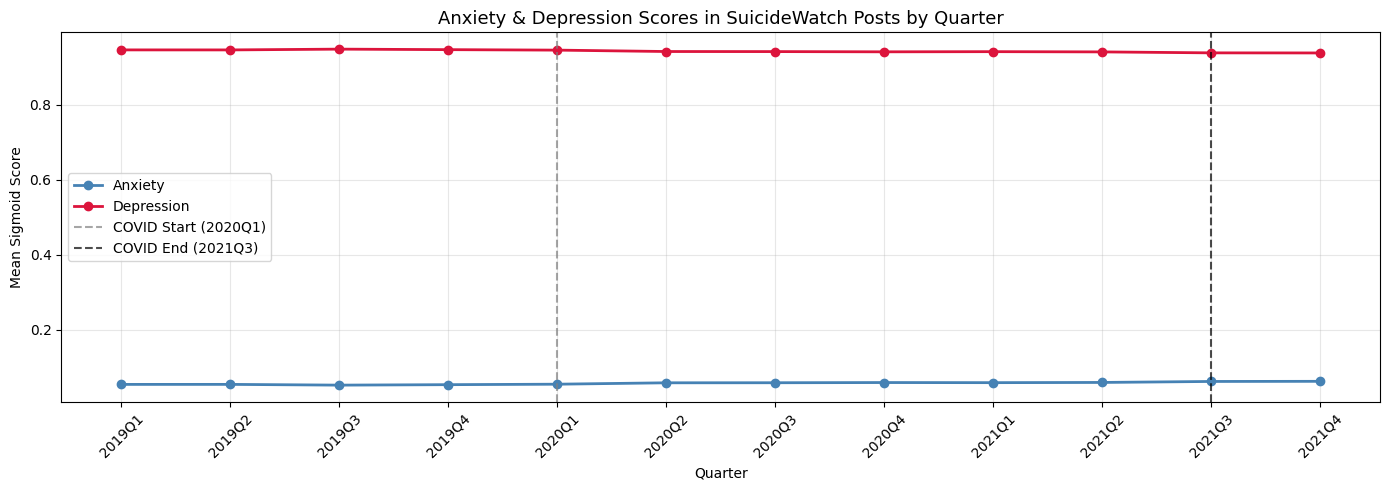

Plot saved -> quarterly_trends.png


In [39]:
# Quarterly Trend Plot

quarterly_means = (final_scores.groupby("quarter")[["anxiety_score", "depression_score"]]
                   .mean().sort_index())

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(quarterly_means.index, quarterly_means["anxiety_score"],
        marker="o", color="steelblue", linewidth=2, label="Anxiety")
ax.plot(quarterly_means.index, quarterly_means["depression_score"],
        marker="o", color="crimson",   linewidth=2, label="Depression")

# Mark COVID period boundaries
covid_start = list(quarterly_means.index).index("2020Q1") if "2020Q1" in quarterly_means.index else None
covid_end   = list(quarterly_means.index).index("2021Q3") if "2021Q3" in quarterly_means.index else None
if covid_start:
    ax.axvline(x=covid_start, color="gray",  linestyle="--", alpha=0.7, label="COVID Start (2020Q1)")
if covid_end:
    ax.axvline(x=covid_end,   color="black", linestyle="--", alpha=0.7, label="COVID End (2021Q3)")

ax.set_title("Anxiety & Depression Scores in SuicideWatch Posts by Quarter", fontsize=13)
ax.set_xlabel("Quarter")
ax.set_ylabel("Mean Sigmoid Score")
ax.set_xticks(range(len(quarterly_means.index)))
ax.set_xticklabels(quarterly_means.index, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("quarterly_trends.png", dpi=150)
upload_to_gcs("quarterly_trends.png", GCS_BUCKET)
plt.show()
print("Plot saved -> quarterly_trends.png")


**Interpretability**

In [41]:
print(pd.read_csv("suicide_scores_final.csv").columns.tolist())

['anxiety_score', 'depression_score', 'period', 'year_month', 'quarter']


Loading suicide_scores_final.csv...
Posts with anxiety_score    >= 0.7: 13,605
Posts with depression_score >= 0.7: 332,386

SHAP sample size for anxiety analysis:    100
SHAP sample size for depression analysis: 100

Sample anxiety text preview:    We want to kill ourselves because some of us exists in the same hell. ......
Sample depression text preview: We want to kill ourselves because some of us exists in the same hell. ......

Loading model and probing heads...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded.

Sanity check — testing predict functions on 3 samples...
  predict_anxiety output:    [0.00439266 0.9802971  0.00351558]
  predict_depression output: [0.9973667  0.01300566 0.9980445 ]
Prediction functions working correctly.

Running SHAP for anxiety dimension...
(This may take 10-20 minutes for 50 posts)


Token indices sequence length is longer than the specified maximum sequence length for this model (1622 > 512). Running this sequence through the model will result in indexing errors
PartitionExplainer explainer: 51it [01:34,  2.01s/it]


SHAP for anxiety done.

Running SHAP for depression dimension...


PartitionExplainer explainer: 51it [01:31,  1.94s/it]


SHAP for depression done.

KEYWORD EXTRACTION RESULTS

Top 20 keywords driving [ANXIETY] score:
Rank   Token                Mean |SHAP|    
------------------------------------------
1      anxiety              0.202508
2      relax                0.053395
3      depressed            0.052906
4      please               0.052033
5      suicide              0.044538
6      hurt                 0.037186
7      leave                0.031655
8      suicidal             0.027298
9      rather               0.026770
10     hopefully            0.022151
11     end                  0.021785
12     kill                 0.020866
13     cut                  0.019385
14     exist                0.018837
15     die                  0.016955
16     fucked               0.015568
17     fuck                 0.015122
18     ing                  0.014958
19     able                 0.014826
20     chance               0.014227

Top 20 keywords driving [DEPRESSION] score:
Rank   Token                Mean

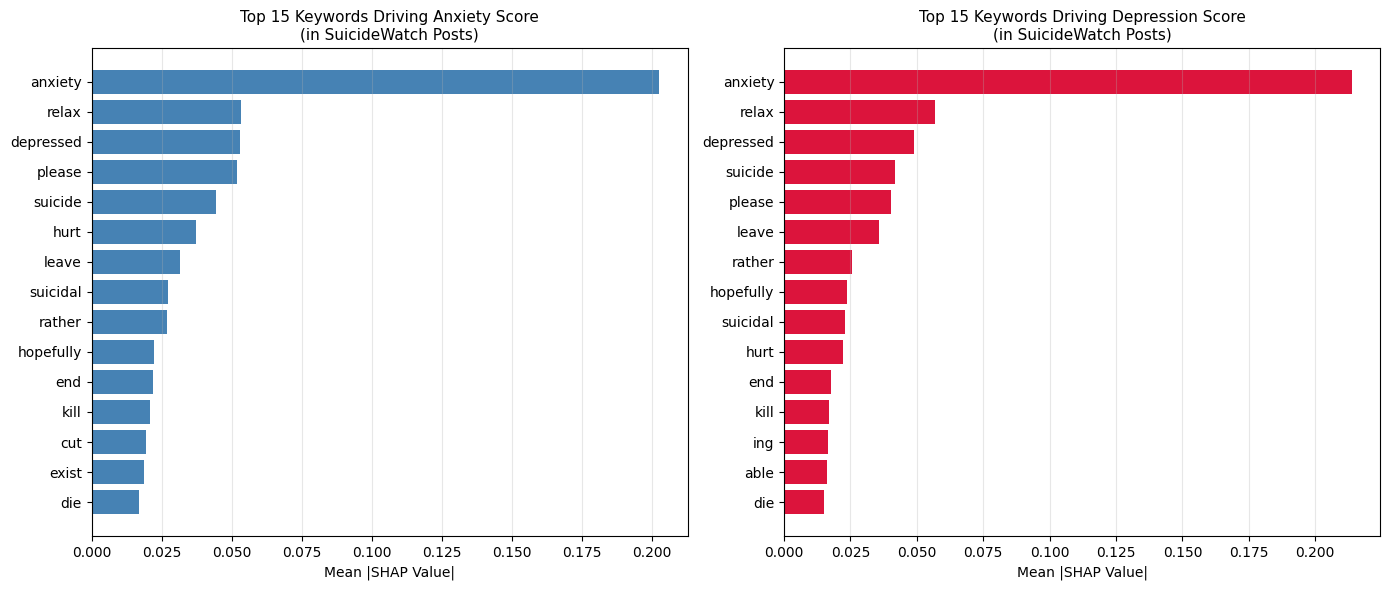

Keyword plot saved -> shap_keywords.png
Hand shap_keywords.csv and shap_keywords.png to Member D.


In [43]:
# SHAP Keyword Extraction
# Goal: For suicidewatch posts with highest anxiety/depression
#       probing scores, identify which words drive each score.
#
# Input:  suicide_scores_final.csv + best_model.pt + probing heads
# Output: shap_keywords.csv -> Member D for visualization

!pip install shap -q

import shap
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import subprocess

# ── Step 1: Load scores and select high-scoring posts ─────────────────────────

print("Loading suicide_scores_final.csv...")
final_scores = pd.read_csv("suicide_scores_final.csv")

HIGH_THRESHOLD = 0.7
N_SHAP_SAMPLES = 100

high_anxiety_posts    = final_scores[final_scores["anxiety_score"]    >= HIGH_THRESHOLD]
high_depression_posts = final_scores[final_scores["depression_score"] >= HIGH_THRESHOLD]

print(f"Posts with anxiety_score    >= {HIGH_THRESHOLD}: {len(high_anxiety_posts):,}")
print(f"Posts with depression_score >= {HIGH_THRESHOLD}: {len(high_depression_posts):,}")

shap_anxiety_df = high_anxiety_posts.sample(
    n=min(N_SHAP_SAMPLES, len(high_anxiety_posts)), random_state=42
).reset_index(drop=True)

shap_depression_df = high_depression_posts.sample(
    n=min(N_SHAP_SAMPLES, len(high_depression_posts)), random_state=42
).reset_index(drop=True)

print(f"\nSHAP sample size for anxiety analysis:    {len(shap_anxiety_df)}")
print(f"SHAP sample size for depression analysis: {len(shap_depression_df)}")

# Pull text from suicidewatch_inference by index
anxiety_texts    = [str(t) for t in suicidewatch_inference.loc[shap_anxiety_df.index, "text"].fillna("").tolist()]
depression_texts = [str(t) for t in suicidewatch_inference.loc[shap_depression_df.index, "text"].fillna("").tolist()]

print(f"\nSample anxiety text preview:    {anxiety_texts[0][:80]}...")
print(f"Sample depression text preview: {depression_texts[0][:80]}...")


# ── Step 2: Reload model and probing heads ────────────────────────────────────

print("\nLoading model and probing heads...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

model = BERTClassifier(
    model_name=CONFIG["model_name"],
    num_labels=CONFIG["num_labels"],
    dropout=CONFIG["dropout"]
).to(device)
checkpoint = torch.load(
    os.path.join(CONFIG["checkpoint_dir"], "best_model.pt"), map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])
for param in model.parameters():
    param.requires_grad = False
model.eval()

anxiety_head    = ProbingHead(input_dim=768).to(device)
depression_head = ProbingHead(input_dim=768).to(device)
anxiety_head.load_state_dict(
    torch.load(os.path.join(CONFIG["checkpoint_dir"], "probing_anxiety.pt"),
               map_location=device)
)
depression_head.load_state_dict(
    torch.load(os.path.join(CONFIG["checkpoint_dir"], "probing_depression.pt"),
               map_location=device)
)
anxiety_head.eval()
depression_head.eval()
print("All models loaded.")


# ── Step 3: Define prediction functions for SHAP ──────────────────────────────

def predict_anxiety(texts):
    """Takes list of strings, returns anxiety probe scores as numpy array."""
    # Force all inputs to native Python strings — SHAP sometimes passes numpy strings
    texts = [str(t) if t is not None else "" for t in texts]
    all_scores = []
    for i in range(0, len(texts), 16):
        batch_texts = texts[i:i+16]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=CONFIG["max_length"],
            return_tensors="pt"
        )
        input_ids      = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        with torch.no_grad():
            emb   = model(input_ids, attention_mask, return_embedding=True)
            score = torch.sigmoid(anxiety_head(emb)).squeeze(1).cpu().numpy()
        all_scores.extend(score)
    return np.array(all_scores)


def predict_depression(texts):
    """Takes list of strings, returns depression probe scores as numpy array."""
    texts = [str(t) if t is not None else "" for t in texts]
    all_scores = []
    for i in range(0, len(texts), 16):
        batch_texts = texts[i:i+16]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=CONFIG["max_length"],
            return_tensors="pt"
        )
        input_ids      = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        with torch.no_grad():
            emb   = model(input_ids, attention_mask, return_embedding=True)
            score = torch.sigmoid(depression_head(emb)).squeeze(1).cpu().numpy()
        all_scores.extend(score)
    return np.array(all_scores)


# ── Step 4: Sanity check prediction functions before running SHAP ─────────────

print("\nSanity check — testing predict functions on 3 samples...")
test_out_a = predict_anxiety(anxiety_texts[:3])
test_out_d = predict_depression(depression_texts[:3])
print(f"  predict_anxiety output:    {test_out_a}")
print(f"  predict_depression output: {test_out_d}")
print("Prediction functions working correctly.")


# ── Step 5: Run SHAP ──────────────────────────────────────────────────────────

print("\nRunning SHAP for anxiety dimension...")
print("(This may take 10-20 minutes for 50 posts)")

masker_anxiety      = shap.maskers.Text(tokenizer)
explainer_anxiety   = shap.Explainer(predict_anxiety, masker_anxiety)
shap_values_anxiety = explainer_anxiety(anxiety_texts[:50])

print("SHAP for anxiety done.")
print("\nRunning SHAP for depression dimension...")

masker_depression      = shap.maskers.Text(tokenizer)
explainer_depression   = shap.Explainer(predict_depression, masker_depression)
shap_values_depression = explainer_depression(depression_texts[:50])

print("SHAP for depression done.")


# ── Step 6: Extract top keywords per dimension ────────────────────────────────

def extract_top_keywords(shap_values_obj, n_top=20, label=""):
    """
    Aggregates SHAP values across all posts and returns the top N
    most important tokens by mean absolute SHAP value.
    """
    token_shap = {}

    for i in range(len(shap_values_obj)):
        tokens = shap_values_obj[i].data
        values = shap_values_obj[i].values

        for token, value in zip(tokens, values):
            token = str(token).strip().lower()
            if len(token) < 2 or token in ["[cls]", "[sep]", "[pad]", "##"]:
                continue
            if token not in token_shap:
                token_shap[token] = []
            token_shap[token].append(abs(float(value)))

    # Require token to appear in at least 3 posts for stability
    token_mean    = {t: np.mean(v) for t, v in token_shap.items() if len(v) >= 3}
    sorted_tokens = sorted(token_mean.items(), key=lambda x: x[1], reverse=True)
    top_tokens    = sorted_tokens[:n_top]

    print(f"\nTop {n_top} keywords driving [{label}] score:")
    print(f"{'Rank':<6} {'Token':<20} {'Mean |SHAP|':<15}")
    print("-" * 42)
    for rank, (token, score) in enumerate(top_tokens, 1):
        print(f"{rank:<6} {token:<20} {score:.6f}")

    return pd.DataFrame(top_tokens, columns=["token", "mean_abs_shap"])


print("\n" + "="*60)
print("KEYWORD EXTRACTION RESULTS")
print("="*60)

anxiety_keywords    = extract_top_keywords(shap_values_anxiety,    n_top=20, label="ANXIETY")
depression_keywords = extract_top_keywords(shap_values_depression, n_top=20, label="DEPRESSION")

anxiety_keywords["dimension"]    = "anxiety"
depression_keywords["dimension"] = "depression"

keywords_df = pd.concat([anxiety_keywords, depression_keywords]).reset_index(drop=True)
keywords_df.to_csv("shap_keywords.csv", index=False)
print(f"\nKeywords saved -> shap_keywords.csv")


# ── Step 7: Printed Interpretation ───────────────────────────────────────────

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

print("""
What these SHAP values mean:
-----------------------------
Each token's Mean |SHAP| value represents how much that word
shifts the probing head's score when it is present in a post.

A high SHAP value for a token means:
  - That word is strongly associated with the dimension being scored
  - Removing it from the post would noticeably reduce the score
  - It is a reliable linguistic marker of that mental health state

Anxiety keywords reflect language patterns the model associates
with anxious posts: words related to worry, uncertainty, physical
symptoms, avoidance, and future-oriented fear.

Depression keywords reflect language patterns the model associates
with depressive posts: words related to hopelessness, fatigue,
worthlessness, withdrawal, and past-oriented rumination.

The fact that these keywords emerge from SUICIDEWATCH posts
(not anxiety/depression posts) means:
  - Anxiety keywords found in suicidewatch posts suggest those posts
    contain anxious language even though they were labeled suicidewatch
  - Depression keywords found in suicidewatch posts suggest strong
    overlap between suicidal and depressive language

These keywords will be handed to Member D for word cloud /
bar chart visualization (Figure 8 in the paper).
""")


# ── Step 8: Quick bar chart (preliminary — Member D will refine) ──────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (dim, color) in zip(axes, [("anxiety", "steelblue"), ("depression", "crimson")]):
    df = keywords_df[keywords_df["dimension"] == dim].head(15)
    ax.barh(df["token"][::-1], df["mean_abs_shap"][::-1], color=color)
    ax.set_title(f"Top 15 Keywords Driving {dim.capitalize()} Score\n(in SuicideWatch Posts)",
                 fontsize=11)
    ax.set_xlabel("Mean |SHAP Value|")
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("shap_keywords.png", dpi=150)
upload_to_gcs("shap_keywords.png", GCS_BUCKET)
upload_to_gcs("shap_keywords.csv", GCS_BUCKET)
plt.show()
print("Keyword plot saved -> shap_keywords.png")
print("Hand shap_keywords.csv and shap_keywords.png to Member D.")